# 🫒 Détection des Maladies de l'Olivier — Deep Learning

---

| Informations | Détails |
|---|---|
| **Encadrant** | M. Abdallah Khemais |
| **Notebook** | 3 / 6 — CNN Simple (Baseline) |
| **Objectif** | Entraîner un CNN from scratch comme référence |
| **Modèle** | CNN maison : 3 blocs Conv + BN + Pool + Dropout |

---

## 🎯 Objectif de ce Notebook

Ce notebook construit un **CNN de base (baseline)** from scratch :
1. ✅ Chargement de la config et reconstruction du pipeline
2. ✅ Construction de l'architecture CNN simple
3. ✅ Compilation avec optimiseur Adam et loss categorical_crossentropy
4. ✅ Entraînement avec **EarlyStopping** et **ModelCheckpoint**
5. ✅ Tracé des **courbes d'apprentissage** (accuracy + loss)
6. ✅ Analyse **overfitting / underfitting**
7. ✅ Évaluation sur le **test set**
8. ✅ **Matrice de confusion** et rapport de classification

---

## 🔑 Concepts clés abordés

| Concept | Rôle dans ce notebook |
|---|---|
| **Conv2D** | Extraction de features (contours, textures, couleurs) |
| **BatchNormalization** | Stabilise l'entraînement, accélère la convergence |
| **MaxPooling2D** | Réduit la dimension spatiale, garde les features importantes |
| **Dropout** | Désactive aléatoirement des neurones → réduit l'overfitting |
| **EarlyStopping** | Arrête l'entraînement si val_loss ne s'améliore plus |
| **Categorical Crossentropy** | Fonction de perte pour classification multi-classes |

---
## 📦 Cellule 1 — Import des Librairies

> **Explication :** On importe toutes les librairies nécessaires.
> Ce notebook est **autonome** : il peut être exécuté indépendamment des notebooks précédents.

In [41]:
# ============================================================
# Cellule 1 — Import des Librairies
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import json
import warnings
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint,
    ReduceLROnPlateau, TensorBoard
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

print('Librairies importées avec succès !')
print(f'  TensorFlow : {tf.__version__}')
print(f'  GPU dispo  : {len(tf.config.list_physical_devices("GPU")) > 0}')

Librairies importées avec succès !
  TensorFlow : 2.19.0
  GPU dispo  : True


---
## ⚙️ Cellule 2 — Chargement Config et Reconstruction Pipeline

> **Explication :** On recharge `config.json` et les splits sauvegardés dans NB2.
> On reconstruit le pipeline `tf.data` pour avoir `train_ds`, `val_ds`, `test_ds`.

In [42]:
# ============================================================
# Cellule 2 — Chargement Config et Reconstruction Pipeline
# On recharge tout ce qui a été préparé dans NB1 et NB2
# ============================================================

# Chargement de la configuration
CONFIG_PATHS = [
    '/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/config.json',
    '/kaggle/input/notebooks/ahmedboudriga/nb1-setup-exploration/config.json',
]

config = None
for path in CONFIG_PATHS:
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f:
            config = json.load(f)
        print(f'Config chargée depuis : {path}')
        break

if config is None:
    raise FileNotFoundError('Aucun config.json trouvé !')

IMG_SIZE    = config['img_size']
BATCH_SIZE  = config['batch_size']
NUM_CLASSES = config['num_classes']
AUTOTUNE    = tf.data.AUTOTUNE

if 'idx_to_class' in config:
    idx_to_class = {int(k): v for k, v in config['idx_to_class'].items()}
else:
    idx_to_class = {i: cls for i, cls in enumerate(config['classes'])}
    print('⚠️  idx_to_class absent → reconstruit depuis classes[]')

CLASS_NAMES = [idx_to_class[i] for i in range(NUM_CLASSES)]

# ── Chargement des splits sauvegardés ────────────────────────────────────────
X_train = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/X_train.npy', allow_pickle=True)
X_val   = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/X_val.npy',   allow_pickle=True)
X_test  = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/X_test.npy',  allow_pickle=True)
y_train = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/y_train.npy')
y_val   = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/y_val.npy')
y_test  = np.load('/kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/y_test.npy')

# ── Correction automatique des chemins périmés ────────────────────────────────
def fix_paths(paths):
    if len(paths) == 0 or os.path.exists(paths[0]):
        return paths  # Chemins déjà valides

    print(f'⚠️  Chemin périmé : {paths[0]}')

    # Trouver le vrai répertoire du dataset dans /kaggle/input/
    dataset_root = None
    for root, dirs, files in os.walk('/kaggle/input/'):
        if os.path.basename(paths[0]) in files:
            dataset_root = root
            break

    if dataset_root is None:
        raise FileNotFoundError('Dataset introuvable dans /kaggle/input/')

    # Remonter jusqu'à la racine commune
    # Structure : .../DatasetRoot/ClassName/image.jpg
    base_old = str(Path(paths[0]).parent.parent)
    base_new = str(Path(dataset_root).parent)

    fixed = np.array([p.replace(base_old, base_new) for p in paths])
    print(f'  Ancien root : {base_old}')
    print(f'  Nouveau root: {base_new}')

    missing = sum(1 for p in fixed if not os.path.exists(p))
    print(f'  Fichiers manquants après correction : {missing} / {len(fixed)}')
    return fixed

print('\nVérification des chemins...')
X_train = fix_paths(X_train)
X_val   = fix_paths(X_val)
X_test  = fix_paths(X_test)
print('Chemins OK ✅')

# ── Augmentation GPU ──────────────────────────────────────────────────────────
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name='data_augmentation')

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment_image(img, label):
    img = data_augmentation(img, training=True)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def build_dataset(paths, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths.tolist(), labels.tolist()))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(X_train, y_train, augment=True,  shuffle=True)
val_ds   = build_dataset(X_val,   y_val,   augment=False, shuffle=False)
test_ds  = build_dataset(X_test,  y_test,  augment=False, shuffle=False)

print('\nPipeline reconstruit !')
print(f'  Classes     : {CLASS_NAMES}')
print(f'  Train       : {len(X_train):,} images')
print(f'  Validation  : {len(X_val):,} images')
print(f'  Test        : {len(X_test):,} images')

Config chargée depuis : /kaggle/input/notebooks/ahmedboudriga/nb2-preprocessing-augmentation/config.json

Vérification des chemins...
Chemins OK ✅

Pipeline reconstruit !
  Classes     : ['Kus_Gozu_Mantari', 'Pas_Akari', 'Saglikli']
  Train       : 686 images
  Validation  : 147 images
  Test        : 147 images


---
## 🏗️ Cellule 3 — Architecture CNN Baseline

> **Explication :** On construit un CNN from scratch avec 3 blocs identiques.
> Chaque bloc suit le pattern classique :
> ```
> Conv2D → BatchNormalization → Activation ReLU → MaxPooling2D → Dropout
> ```
> - **Conv2D** : apprend des filtres qui détectent les features visuelles (bords, taches, textures)
> - **BatchNormalization** : normalise les activations → évite le gradient vanishing
> - **ReLU** : `f(x) = max(0, x)` → introduit la non-linéarité
> - **MaxPooling2D** : réduit la résolution spatiale de moitié
> - **Dropout** : désactive p% des neurones aléatoirement → régularisation
>
> **Architecture complète :**
> ```
> Input (224,224,3)
>   └─ Bloc 1 : Conv(32) → BN → ReLU → MaxPool → Dropout(0.25)
>   └─ Bloc 2 : Conv(64) → BN → ReLU → MaxPool → Dropout(0.25)
>   └─ Bloc 3 : Conv(128) → BN → ReLU → MaxPool → Dropout(0.25)
>   └─ GlobalAveragePooling
>   └─ Dense(256) → BN → ReLU → Dropout(0.5)
>   └─ Dense(3, softmax)  ← 3 classes
> ```

In [43]:
# ============================================================
# Cellule 3 — Architecture CNN Baseline (from scratch)
# 3 blocs Conv + BN + MaxPool + Dropout → Dense → Softmax
# ============================================================

def build_cnn_baseline(input_shape=(224, 224, 3), num_classes=3):
    """
    CNN maison (baseline) pour classification de maladies de l'olivier.
    Architecture : 3 blocs convolutifs + tête de classification.
    """
    inputs = layers.Input(shape=input_shape, name='input_layer')

    # ── Bloc 1 : 32 filtres 3×3 ─────────────────────────────
    # Détecte les features de bas niveau : bords, gradients
    x = layers.Conv2D(32, (3, 3), padding='same', name='conv1_1')(inputs)
    x = layers.BatchNormalization(name='bn1_1')(x)    # Normalise les activations
    x = layers.Activation('relu', name='relu1_1')(x)  # Activation non-linéaire
    x = layers.Conv2D(32, (3, 3), padding='same', name='conv1_2')(x)
    x = layers.BatchNormalization(name='bn1_2')(x)
    x = layers.Activation('relu', name='relu1_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)  # 224→112
    x = layers.Dropout(0.25, name='drop1')(x)         # Régularisation 25%

    # ── Bloc 2 : 64 filtres 3×3 ─────────────────────────────
    # Détecte les features de niveau moyen : textures, taches
    x = layers.Conv2D(64, (3, 3), padding='same', name='conv2_1')(x)
    x = layers.BatchNormalization(name='bn2_1')(x)
    x = layers.Activation('relu', name='relu2_1')(x)
    x = layers.Conv2D(64, (3, 3), padding='same', name='conv2_2')(x)
    x = layers.BatchNormalization(name='bn2_2')(x)
    x = layers.Activation('relu', name='relu2_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)  # 112→56
    x = layers.Dropout(0.25, name='drop2')(x)

    # ── Bloc 3 : 128 filtres 3×3 ────────────────────────────
    # Détecte les features de haut niveau : formes, patterns de maladie
    x = layers.Conv2D(128, (3, 3), padding='same', name='conv3_1')(x)
    x = layers.BatchNormalization(name='bn3_1')(x)
    x = layers.Activation('relu', name='relu3_1')(x)
    x = layers.Conv2D(128, (3, 3), padding='same', name='conv3_2')(x)
    x = layers.BatchNormalization(name='bn3_2')(x)
    x = layers.Activation('relu', name='relu3_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool3')(x)  # 56→28
    x = layers.Dropout(0.25, name='drop3')(x)

    # ── Tête de Classification ───────────────────────────────
    # GlobalAveragePooling : réduit (28,28,128) → (128,)
    # Plus efficace que Flatten : moins de paramètres, moins d'overfitting
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(256, name='dense1')(x)
    x = layers.BatchNormalization(name='bn_dense')(x)
    x = layers.Activation('relu', name='relu_dense')(x)
    x = layers.Dropout(0.5, name='drop_dense')(x)     # Dropout fort en tête

    # Couche de sortie : softmax → probabilités pour chaque classe
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='CNN_Baseline')
    return model

# Création du modèle
cnn_model = build_cnn_baseline(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES
)

# Résumé de l'architecture
cnn_model.summary()

# Nombre total de paramètres
total_params = cnn_model.count_params()
print(f'\nNombre total de paramètres : {total_params:,}')

Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_1 (Activation)            │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_2 (Activation)            │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_1 (Activation)            │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_2 (Activation)            │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_1 (Activation)            │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_2 (Activation)            │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 28, 28, 128)    │             

 Total params: 323,619 (1.23 MB)

 Trainable params: 322,211 (1.23 MB)

 Non-trainable params: 1,408 (5.50 KB)


Nombre total de paramètres : 323,619


---
## ⚙️ Cellule 4 — Compilation du Modèle

> **Explication :** La compilation configure 3 éléments essentiels :
> - **Optimiseur Adam** : calcule les gradients et met à jour les poids
>   - `lr=1e-4` : taux d'apprentissage initial (ni trop grand, ni trop petit)
> - **Loss : Sparse Categorical Crossentropy** : mesure l'erreur pour la classification multi-classes
>   - `sparse` = les labels sont des entiers (0, 1, 2) et non des vecteurs one-hot
> - **Métriques** : `accuracy` pour suivre les performances en temps réel
>
> **Formule de la Crossentropy :**
> ```
> L = -Σ y_i × log(ŷ_i)
> ```
> Plus la prédiction est proche de la vraie classe, plus la loss est faible.

In [44]:
# ============================================================
# Cellule 4 — Compilation du Modèle
# Optimiseur Adam + Loss CrossEntropy + Métrique Accuracy
# ============================================================

# Taux d'apprentissage initial
LEARNING_RATE = config['learning_rate']  # 1e-4 = 0.0001

# Compilation
cnn_model.compile(
    # Adam : adapte le lr pour chaque paramètre individuellement
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),

    # SparseCategoricalCrossentropy : labels sont des entiers (0, 1, 2)
    # Si les labels étaient en one-hot → utiliser CategoricalCrossentropy
    loss=keras.losses.SparseCategoricalCrossentropy(),

    # Métriques suivies pendant l'entraînement
    metrics=['accuracy']
)

print('Modèle compilé avec succès !')
print(f'  Optimiseur  : Adam (lr={LEARNING_RATE})')
print(f'  Loss        : SparseCategoricalCrossentropy')
print(f'  Métriques   : accuracy')
print(f'  Paramètres  : {cnn_model.count_params():,}')

Modèle compilé avec succès !
  Optimiseur  : Adam (lr=0.0001)
  Loss        : SparseCategoricalCrossentropy
  Métriques   : accuracy
  Paramètres  : 323,619


---
## 📋 Cellule 5 — Définition des Callbacks

> **Explication :** Les **callbacks** sont des fonctions appelées automatiquement pendant l'entraînement :
>
> | Callback | Rôle |
> |---|---|
> | **EarlyStopping** | Arrête si val_loss ne s'améliore pas pendant N époques → évite l'overfitting |
> | **ModelCheckpoint** | Sauvegarde automatiquement le meilleur modèle (best val_accuracy) |
> | **ReduceLROnPlateau** | Réduit le learning rate si val_loss stagne → aide à converger |
>
> **EarlyStopping avec restore_best_weights=True** : à la fin, les poids du meilleur epoch sont restaurés automatiquement.

In [45]:
# ============================================================
# Cellule 5 — Définition des Callbacks
# EarlyStopping + ModelCheckpoint + ReduceLROnPlateau
# ============================================================

CNN_MODEL_PATH = '/kaggle/working/cnn_baseline_best.h5'

callbacks = [

    # Arrêt anticipé si val_loss ne s'améliore pas pendant 7 époques
    # restore_best_weights=True : revient aux poids du meilleur epoch
    EarlyStopping(
        monitor='val_loss',        # Surveille la val_loss
        patience=7,                # Attend 7 époques sans amélioration
        restore_best_weights=True, # Revient aux meilleurs poids
        verbose=1
    ),

    # Sauvegarde du meilleur modèle (selon val_accuracy)
    ModelCheckpoint(
        filepath=CNN_MODEL_PATH,
        monitor='val_accuracy',    # Sauvegarde quand val_accuracy est max
        save_best_only=True,       # Ne sauvegarde que le meilleur
        verbose=1
    ),

    # Réduction du learning rate si val_loss stagne pendant 4 époques
    # factor=0.5 : lr = lr * 0.5 (on divise par 2)
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,                # Nouveau lr = ancien lr × 0.5
        patience=4,                # Attend 4 époques avant de réduire
        min_lr=1e-7,               # Valeur minimale du learning rate
        verbose=1
    ),
]

print('Callbacks configurés :')
print(f'  EarlyStopping       : patience=7, monitor=val_loss')
print(f'  ModelCheckpoint     : save_best_only=True, monitor=val_accuracy')
print(f'  ReduceLROnPlateau   : factor=0.5, patience=4, min_lr=1e-7')
print(f'  Modèle sauvegardé → : {CNN_MODEL_PATH}')

Callbacks configurés :
  EarlyStopping       : patience=7, monitor=val_loss
  ModelCheckpoint     : save_best_only=True, monitor=val_accuracy
  ReduceLROnPlateau   : factor=0.5, patience=4, min_lr=1e-7
  Modèle sauvegardé → : /kaggle/working/cnn_baseline_best.h5


---
## 🚀 Cellule 6 — Entraînement du CNN Baseline

> **Explication :** On lance l'entraînement du modèle.
> - À chaque **epoch**, le modèle voit tout le train set
> - Après chaque epoch, on évalue sur le **val set**
> - Le modèle **ajuste ses poids** via la rétropropagation (backpropagation)
> - L'**EarlyStopping** arrête automatiquement si ça n'améliore plus
>
> **Durée estimée** : ~5–10 minutes sur GPU T4 Kaggle (30 epochs max)

In [46]:
# ============================================================
# Cellule 6 — Entraînement du CNN Baseline
# On lance model.fit() avec les callbacks définis
# ============================================================

EPOCHS = config['epochs']  # 30 epochs max (EarlyStopping peut arrêter avant)

print('Début de l\'entraînement du CNN Baseline...')
print(f'  Epochs max  : {EPOCHS}')
print(f'  Batch size  : {BATCH_SIZE}')
print(f'  Train batches par epoch : {len(list(train_ds))}')
print()

history_cnn = cnn_model.fit(
    train_ds,                          # Dataset d'entraînement
    epochs=EPOCHS,                     # Nombre max d'époques
    validation_data=val_ds,            # Dataset de validation
    callbacks=callbacks,               # Callbacks actifs
    verbose=1                          # Affichage de la progression
)

print()
print('Entraînement terminé !')
print(f'  Epochs effectuées : {len(history_cnn.history["loss"])}')
print(f'  Meilleur val_accuracy : {max(history_cnn.history["val_accuracy"]):.4f}')
print(f'  Meilleur val_loss     : {min(history_cnn.history["val_loss"]):.4f}')

Début de l'entraînement du CNN Baseline...
  Epochs max  : 30
  Batch size  : 32
  Train batches par epoch : 22

Epoch 1/30


I0000 00:00:1778687975.005119     140 service.cc:152] XLA service 0x7f4c64004f90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778687975.005171     140 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778687975.005177     140 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778687976.297157     140 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-13 15:59:42.678130: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-13 15:59:42.834245: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-13 15:59:45.774002: E external/local_xl

 1/22 ━━━━━━━━━━━━━━━━━━━━ 9:25 27s/step - accuracy: 0.4062 - loss: 1.1852

I0000 00:00:1778687996.727843     140 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.4481 - loss: 1.2573

2026-05-13 16:00:06.769052: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-13 16:00:06.920257: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-13 16:00:08.491400: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-13 16:00:08.777195: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 912ms/step - accuracy: 0.4510 - loss: 1.2519
Epoch 1: val_accuracy improved from -inf to 0.46939, saving model to /kaggle/working/cnn_baseline_best.h5


22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.4537 - loss: 1.2470 - val_accuracy: 0.4694 - val_loss: 1.0896 - learning_rate: 1.0000e-04
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.5736 - loss: 1.0209
Epoch 2: val_accuracy did not improve from 0.46939
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 348ms/step - accuracy: 0.5737 - loss: 1.0203 - val_accuracy: 0.4694 - val_loss: 1.0848 - learning_rate: 1.0000e-04
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.6558 - loss: 0.8562
Epoch 3: val_accuracy did not improve from 0.46939
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 343ms/step - accuracy: 0.6560 - loss: 0.8566 - val_accuracy: 0.4694 - val_loss: 1.0787 - learning_rate: 1.0000e-04
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.6470 - loss: 0.8150
Epoch 4: val_accuracy did not improve from 0.46939
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 343ms/step - accuracy: 0.6470 - loss: 0.8163 - val_accuracy: 0.4694 - val_loss: 1.0828 - learning_rate: 1.0000e-04
Epoch 5/30


---
## 📈 Cellule 7 — Courbes d'Apprentissage

> **Explication :** Les courbes d'apprentissage montrent l'évolution de la **loss** et de l'**accuracy** epoch par epoch.
> Elles permettent de détecter :
> - ✅ **Bonne convergence** : train et val descendent ensemble
> - ⚠️ **Overfitting** : train continue à baisser mais val remonte
> - ⚠️ **Underfitting** : les deux restent élevées, le modèle n'apprend pas
> - ⚠️ **Instabilité** : courbes très oscillantes → lr trop élevé

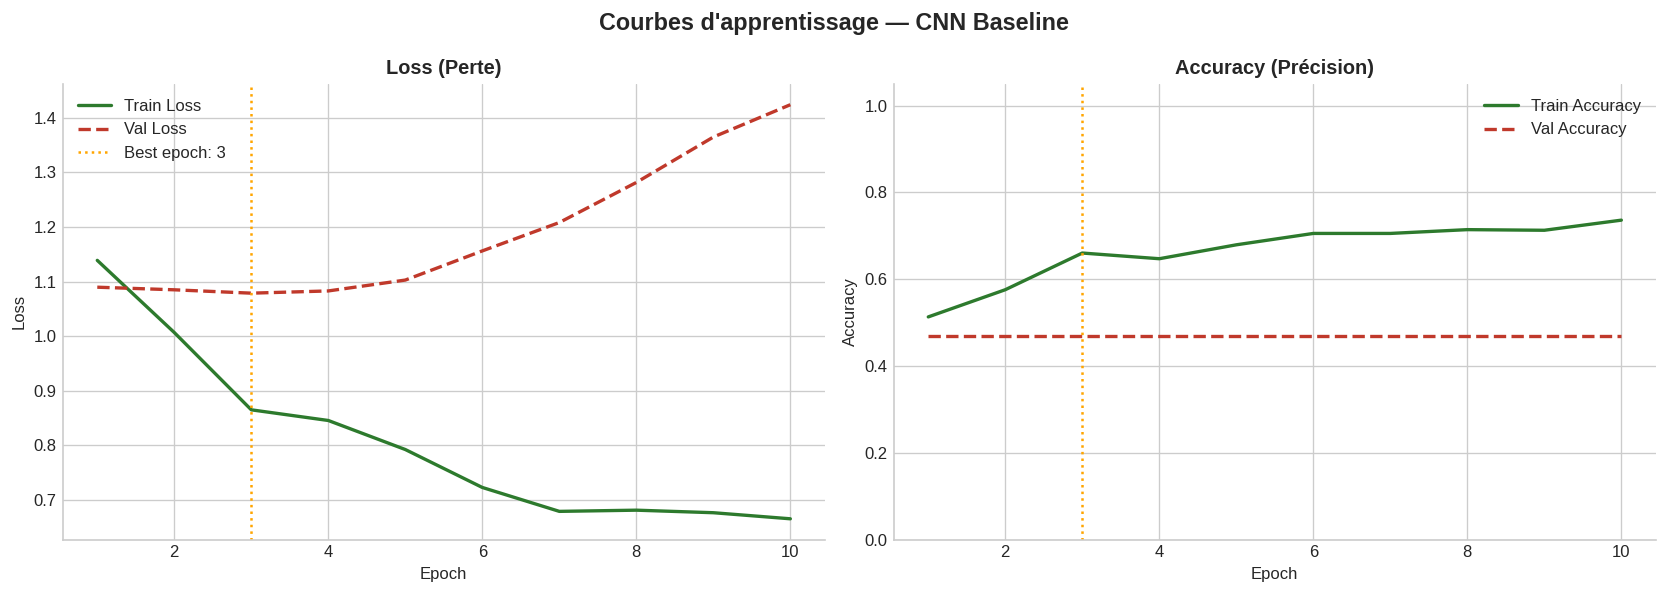

Figure sauvegardée --> /kaggle/working/08_learning_curves_CNN_Baseline.png

Diagnostic :
  Train accuracy finale : 0.7362
  Val accuracy finale   : 0.4694
  Écart (gap)           : 0.2668
  --> Overfitting détecté (gap > 10%)
  --> Solutions : plus de Dropout, moins de couches, plus de data


In [47]:
# ============================================================
# Cellule 7 — Courbes d'Apprentissage
# Visualisation de la loss et accuracy (train vs validation)
# ============================================================

def plot_learning_curves(history, model_name='CNN Baseline'):
    """Trace les courbes loss et accuracy train vs validation."""
    hist = history.history
    epochs_range = range(1, len(hist['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'Courbes d\'apprentissage — {model_name}',
        fontsize=14, fontweight='bold'
    )

    # ── Courbe Loss ────────────────────────────────────────
    axes[0].plot(epochs_range, hist['loss'],     label='Train Loss',
                 color='#2d7a2d', linewidth=2)
    axes[0].plot(epochs_range, hist['val_loss'], label='Val Loss',
                 color='#c0392b', linewidth=2, linestyle='--')
    axes[0].set_title('Loss (Perte)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].spines[['top', 'right']].set_visible(False)

    # Marqueur de la meilleure epoch
    best_epoch = np.argmin(hist['val_loss']) + 1
    axes[0].axvline(best_epoch, color='orange', linestyle=':', linewidth=1.5,
                    label=f'Best epoch: {best_epoch}')
    axes[0].legend()

    # ── Courbe Accuracy ────────────────────────────────────
    axes[1].plot(epochs_range, hist['accuracy'],     label='Train Accuracy',
                 color='#2d7a2d', linewidth=2)
    axes[1].plot(epochs_range, hist['val_accuracy'], label='Val Accuracy',
                 color='#c0392b', linewidth=2, linestyle='--')
    axes[1].set_title('Accuracy (Précision)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1.05)
    axes[1].axvline(best_epoch, color='orange', linestyle=':', linewidth=1.5)
    axes[1].legend()
    axes[1].spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    save_path = f'/kaggle/working/08_learning_curves_{model_name.replace(" ", "_")}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure sauvegardée --> {save_path}')

    # Diagnostic overfitting
    last_train_acc = hist['accuracy'][-1]
    last_val_acc   = hist['val_accuracy'][-1]
    gap = last_train_acc - last_val_acc
    print(f'\nDiagnostic :')
    print(f'  Train accuracy finale : {last_train_acc:.4f}')
    print(f'  Val accuracy finale   : {last_val_acc:.4f}')
    print(f'  Écart (gap)           : {gap:.4f}')
    if gap > 0.10:
        print('  --> Overfitting détecté (gap > 10%)')
        print('  --> Solutions : plus de Dropout, moins de couches, plus de data')
    elif last_val_acc < 0.70:
        print('  --> Underfitting (val_acc < 70%)')
        print('  --> Solutions : plus d\'epochs, modèle plus complexe')
    else:
        print('  --> Bonne convergence !')

plot_learning_curves(history_cnn, 'CNN Baseline')

---
## 📊 Cellule 8 — Évaluation sur le Test Set

> **Explication :** On évalue le modèle sur le **test set** — des images jamais vues pendant l'entraînement.
> C'est la mesure la plus honnête des performances réelles du modèle.
> - Le **test set** simule des nouvelles photos de feuilles d'olivier à diagnostiquer
> - On calcule : **accuracy**, **loss**, **F1-score** par classe
> - **F1-score** = compromis entre précision (Precision) et rappel (Recall)

In [48]:
# ============================================================
# Cellule 8 — Évaluation sur le Test Set
# Accuracy, Loss, F1-score, Rapport de classification
# ============================================================

# Évaluation globale
test_loss, test_acc = cnn_model.evaluate(test_ds, verbose=0)

print('=' * 55)
print('Résultats sur le Test Set — CNN Baseline')
print('=' * 55)
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print('=' * 55)

# Prédictions sur tout le test set
y_pred_proba = cnn_model.predict(test_ds, verbose=0)  # Probabilités
y_pred       = np.argmax(y_pred_proba, axis=1)         # Classe prédite
y_true       = y_test                                  # Vraies classes

# Rapport de classification détaillé
print('\nRapport de classification :')
print(classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    digits=4
))

# Sauvegarde des résultats
config['cnn_baseline_test_acc']  = float(test_acc)
config['cnn_baseline_test_loss'] = float(test_loss)

Résultats sur le Test Set — CNN Baseline
  Test Loss     : 1.0817
  Test Accuracy : 0.4694 (46.94%)

Rapport de classification :
                  precision    recall  f1-score   support

Kus_Gozu_Mantari     0.4694    1.0000    0.6389        69
       Pas_Akari     0.0000    0.0000    0.0000        44
        Saglikli     0.0000    0.0000    0.0000        34

        accuracy                         0.4694       147
       macro avg     0.1565    0.3333    0.2130       147
    weighted avg     0.2203    0.4694    0.2999       147



---
## 🔲 Cellule 9 — Matrice de Confusion

> **Explication :** La **matrice de confusion** montre les prédictions du modèle pour chaque classe.
> - La **diagonale** = prédictions correctes (TP)
> - Les cases hors diagonale = erreurs (FP / FN)
> - Elle permet de voir **quelles classes** le modèle confond le plus
> - Par exemple : confond-il souvent Peacock Spot avec Aculus Olearius ?

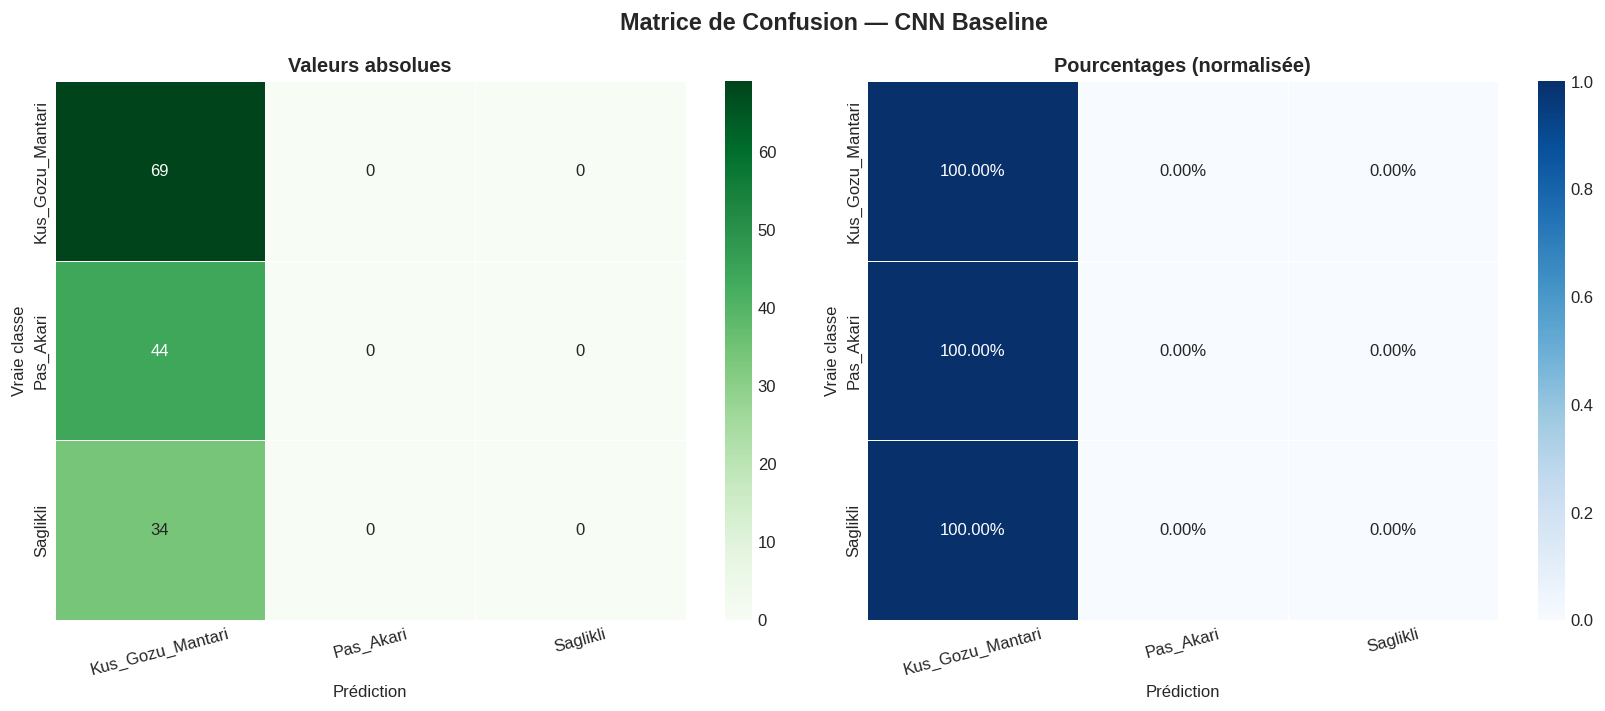

Figure sauvegardée --> /kaggle/working/09_confusion_matrix_CNN_Baseline.png

Analyse des erreurs :
  Kus_Gozu_Mantari          : 69 corrects, 0 erreurs
  Pas_Akari                 : 0 corrects, 44 erreurs
  Saglikli                  : 0 corrects, 34 erreurs


In [49]:
# ============================================================
# Cellule 9 — Matrice de Confusion
# Visualisation des prédictions correctes et erreurs par classe
# ============================================================

def plot_confusion_matrix(y_true, y_pred, class_names, model_name='CNN Baseline'):
    """Trace la matrice de confusion normalisée et brute."""

    cm       = confusion_matrix(y_true, y_pred)
    cm_norm  = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalisation

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        f'Matrice de Confusion — {model_name}',
        fontsize=14, fontweight='bold'
    )

    # ── Matrice brute (nombres absolus) ────────────────────
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Greens',
        xticklabels=class_names, yticklabels=class_names,
        ax=axes[0], linewidths=0.5
    )
    axes[0].set_title('Valeurs absolues', fontweight='bold')
    axes[0].set_xlabel('Prédiction')
    axes[0].set_ylabel('Vraie classe')
    axes[0].tick_params(axis='x', rotation=15)

    # ── Matrice normalisée (pourcentages) ──────────────────
    sns.heatmap(
        cm_norm, annot=True, fmt='.2%', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        ax=axes[1], linewidths=0.5
    )
    axes[1].set_title('Pourcentages (normalisée)', fontweight='bold')
    axes[1].set_xlabel('Prédiction')
    axes[1].set_ylabel('Vraie classe')
    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    save_path = f'/kaggle/working/09_confusion_matrix_{model_name.replace(" ", "_")}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure sauvegardée --> {save_path}')

    # Analyse des erreurs
    print('\nAnalyse des erreurs :')
    for i, cls in enumerate(class_names):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        print(f'  {cls:<25} : {tp} corrects, {fn} erreurs')

plot_confusion_matrix(y_true, y_pred, CLASS_NAMES, 'CNN Baseline')

---
## 💾 Cellule 10 — Sauvegarde des Résultats

> **Explication :** On sauvegarde les résultats du CNN baseline pour les **comparer** avec ResNet et EfficientNet dans NB4 et NB5.
> Le tableau de comparaison final sera présenté dans le NB6 (notebook final).

In [50]:
# ============================================================
# Cellule 10 — Sauvegarde des Résultats
# On enregistre les résultats pour la comparaison dans NB6
# ============================================================

# Mise à jour de la config avec les résultats
config['results'] = config.get('results', {})
config['results']['CNN_Baseline'] = {
    'test_accuracy'  : round(float(test_acc), 4),
    'test_loss'      : round(float(test_loss), 4),
    'total_params'   : cnn_model.count_params(),
    'epochs_trained' : len(history_cnn.history['loss']),
    'best_val_acc'   : round(float(max(history_cnn.history['val_accuracy'])), 4),
    'model_path'     : CNN_MODEL_PATH,
}

# Sauvegarde config mise à jour
with open('/kaggle/working/config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

# Sauvegarde de l'historique
history_df = pd.DataFrame(history_cnn.history)
history_df.to_csv('/kaggle/working/history_cnn_baseline.csv', index=False)

print('=' * 55)
print('Résultats CNN Baseline sauvegardés !')
print('=' * 55)
res = config['results']['CNN_Baseline']
print(f'  Test Accuracy  : {res["test_accuracy"]*100:.2f}%')
print(f'  Test Loss      : {res["test_loss"]:.4f}')
print(f'  Params         : {res["total_params"]:,}')
print(f'  Epochs         : {res["epochs_trained"]}')
print(f'  Best Val Acc   : {res["best_val_acc"]*100:.2f}%')
print('=' * 55)
print(f'\nModèle sauvegardé → {CNN_MODEL_PATH}')

Résultats CNN Baseline sauvegardés !
  Test Accuracy  : 46.94%
  Test Loss      : 1.0817
  Params         : 323,619
  Epochs         : 10
  Best Val Acc   : 46.94%

Modèle sauvegardé → /kaggle/working/cnn_baseline_best.h5


---
## ✅ Récapitulatif du Notebook 3

| Cellule | Tâche | Statut |
|---------|-------|--------|
| 1 | Import des librairies | ✅ |
| 2 | Chargement config + reconstruction pipeline | ✅ |
| 3 | Architecture CNN Baseline (from scratch) | ✅ |
| 4 | Compilation Adam + CrossEntropy | ✅ |
| 5 | Callbacks (EarlyStopping, Checkpoint, ReduceLR) | ✅ |
| 6 | Entraînement model.fit() | ✅ |
| 7 | Courbes d'apprentissage (loss + accuracy) | ✅ |
| 8 | Évaluation test set + rapport classification | ✅ |
| 9 | Matrice de confusion | ✅ |
| 10 | Sauvegarde résultats pour comparaison | ✅ |

---

### 📁 Fichiers générés dans `/kaggle/working/` :
- `cnn_baseline_best.h5` — Meilleur modèle CNN sauvegardé
- `history_cnn_baseline.csv` — Historique de l'entraînement
- `08_learning_curves_CNN_Baseline.png` — Courbes d'apprentissage
- `09_confusion_matrix_CNN_Baseline.png` — Matrice de confusion

---

### 🚀 Prochain Notebook — NB4 : Transfer Learning (ResNet50 vs VGG16)
- Chargement de ResNet50 et VGG16 pré-entraînés sur ImageNet
- Fine-tuning progressif (dégel des couches)
- Comparaison des performances avec le CNN Baseline
- Analyse du gradient vanishing dans les architectures profondes